# Exercise 4 — Audio Classification
### Quran Reciter Identifier

---

## The Problem

An Islamic studies platform wants to automatically identify which Quran reciter
is speaking in an audio clip, to help users find recordings by their preferred reciter.

You are given a dataset of short audio recordings labeled by reciter.
Build a classifier that identifies the reciter from the audio alone.

---

## The Data

```python
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/mohammedalrajeh/quran-recitations-for-audio-classification")
```

A CSV file (`files_paths.csv`) maps audio file paths to reciter labels.
Audio files are `.wav` format stored in subdirectories.

⚠️ **This modality was not given to you in the lectures.**
You need to figure out how to turn audio into something a neural network can process.
That is part of the exercise. Start here: `pip install librosa`

---

## What You Need to Deliver

A working Colab notebook that contains:

1. **A trained PyTorch model** that identifies the Quran reciter from an audio clip
2. **A brief written explanation** (in a markdown cell) of how you converted
   audio into a format the model could process — what did you use and why
3. **A training report** — loss and accuracy curves for train and validation
4. **A test accuracy score**
5. **A live inference demo** — given an audio file path, the model returns the predicted reciter

The model architecture and the full pipeline are yours to design.

---

In [37]:
# Install necessary libraries for audio processing and data downloading
!pip install librosa soundfile kagglehub -q

import librosa
import soundfile as sf
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import random
from typing import Tuple, Dict, List
import kagglehub
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from pathlib import Path
import torch
from torch.utils.data import Dataset, DataLoader
import librosa
import librosa.display
from torch.optim import lr_scheduler
import copy




print("✅ Audio libraries (librosa, soundfile) installed and imported successfully!")

✅ Audio libraries (librosa, soundfile) installed and imported successfully!


In [2]:
# --- Master Configuration ---
CONFIG = {
    "dataset_name": "mohammedalrajeh/quran-recitations-for-audio-classification",
    "csv_file": "files_paths.csv",
    "img_size": (128, 128),     # Target shape for Mel Spectrogram (n_mels, time_steps)
    "sample_rate": 22050,       # Standard sample rate for librosa
    "audio_duration": 3,        # Fixed duration in seconds to pad/truncate audio
    "batch_size": 32,           
    "learning_rate": 1e-3,
    "num_epochs": 30,
    "dropout_rate": 0.3,
    "seed": 42,
    "num_workers": 2
}

# --- Environment Setup ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])
random.seed(CONFIG['seed'])

print(f"🚀 Using device: {DEVICE}")
print(f"🎵 Sample Rate: {CONFIG['sample_rate']} Hz")
print(f"📏 Fixed Audio Duration: {CONFIG['audio_duration']}s")

🚀 Using device: cuda
🎵 Sample Rate: 22050 Hz
📏 Fixed Audio Duration: 3s


In [4]:
def get_dataset_path(dataset_name: str, csv_filename: str) -> Path:
    """
    Checks if the dataset is already downloaded. 
    If yes, skips download. If no, downloads it.
    """
    # kagglehub stores datasets in ~/.cache/kagglehub/datasets/
    cache_dir = Path.home() / ".cache" / "kagglehub" / "datasets" / dataset_name
    
    # Check if the directory and the specific CSV file exist
    if cache_dir.exists() and (cache_dir / csv_filename).exists():
        print(f"✅ Dataset already exists at {cache_dir}. Skipping download!")
        return cache_dir
    else:
        print(f" Dataset not found locally. Downloading '{dataset_name}'...")
        path = kagglehub.dataset_download(dataset_name)
        print(f"✅ Download complete!")
        return Path(path)

# 1. Get the dataset path (smart download)
DATASET_ROOT = get_dataset_path(CONFIG['dataset_name'], CONFIG['csv_file'])

# 2. Locate the CSV file
csv_path = DATASET_ROOT / CONFIG['csv_file']

# 3. Verify & peek at the data
if csv_path.exists():
    df_full = pd.read_csv(csv_path)
    print(f"\n📄 Found {CONFIG['csv_file']} with {len(df_full)} audio clips.")
    print("\n First 5 rows of the dataset:")
    print(df_full.head())
else:
    print(f"❌ Error: {CONFIG['csv_file']} not found in the downloaded directory.")
    # Fallback to list files if CSV is missing
    print("\n Directory contents:")
    for path in DATASET_ROOT.iterdir():
        print(f" - {path.name}")

 Dataset not found locally. Downloading 'mohammedalrajeh/quran-recitations-for-audio-classification'...


100%|██████████| 2.12G/2.12G [01:43<00:00, 22.0MB/s]

Extracting files...


✅ Download complete!

📄 Found files_paths.csv with 6687 audio clips.

 First 5 rows of the dataset:
                                        FilePath               Class
0  ./Dataset/Mohammed_Aluhaidan/lohaidan_171.wav  Mohammed_Aluhaidan
1  ./Dataset/Mohammed_Aluhaidan/lohaidan_159.wav  Mohammed_Aluhaidan
2  ./Dataset/Mohammed_Aluhaidan/lohaidan_401.wav  Mohammed_Aluhaidan
3  ./Dataset/Mohammed_Aluhaidan/lohaidan_367.wav  Mohammed_Aluhaidan
4  ./Dataset/Mohammed_Aluhaidan/lohaidan_373.wav  Mohammed_Aluhaidan


In [8]:
# Load the CSV to inspect column names
csv_path = DATASET_ROOT / CONFIG['csv_file']
df_inspect = pd.read_csv(csv_path)

print("="*60)
print("📋 CSV FILE INSPECTION")
print("="*60)
print(f"\n✅ Column names found:")
print(df_inspect.columns.tolist())

print(f"\n📊 First 5 rows of data:")
print(df_inspect.head())

print(f"\n📐 Dataset shape: {df_inspect.shape[0]} rows × {df_inspect.shape[1]} columns")
print("="*60)

# Auto-detect the columns
print("\n🔍 Attempting to auto-detect column names...")
possible_path_cols = ['filepath', 'path', 'file', 'audio_path', 'filename']
possible_label_cols = ['label', 'reciter', 'class', 'speaker', 'category']

detected_path_col = None
detected_label_col = None

for col in df_inspect.columns:
    col_lower = col.lower()
    if any(keyword in col_lower for keyword in possible_path_cols):
        detected_path_col = col
    if any(keyword in col_lower for keyword in possible_label_cols):
        detected_label_col = col

if detected_path_col:
    print(f"   ✅ Detected PATH_COL: '{detected_path_col}'")
else:
    print(f"   ⚠️  PATH_COL not auto-detected. Please check manually above.")
    
if detected_label_col:
    print(f"   ✅ Detected LABEL_COL: '{detected_label_col}'")
else:
    print(f"   ⚠️  LABEL_COL not auto-detected. Please check manually above.")

print("="*60)

📋 CSV FILE INSPECTION

✅ Column names found:
['FilePath', 'Class']

📊 First 5 rows of data:
                                        FilePath               Class
0  ./Dataset/Mohammed_Aluhaidan/lohaidan_171.wav  Mohammed_Aluhaidan
1  ./Dataset/Mohammed_Aluhaidan/lohaidan_159.wav  Mohammed_Aluhaidan
2  ./Dataset/Mohammed_Aluhaidan/lohaidan_401.wav  Mohammed_Aluhaidan
3  ./Dataset/Mohammed_Aluhaidan/lohaidan_367.wav  Mohammed_Aluhaidan
4  ./Dataset/Mohammed_Aluhaidan/lohaidan_373.wav  Mohammed_Aluhaidan

📐 Dataset shape: 6687 rows × 2 columns

🔍 Attempting to auto-detect column names...
   ✅ Detected PATH_COL: 'FilePath'
   ✅ Detected LABEL_COL: 'Class'


# Audio Exploration

In [18]:


# --- CORRECT COLUMN NAMES ---
PATH_COL = 'FilePath'   
LABEL_COL = 'Class'     

def find_valid_audio_path(row_path: str, base_dir: Path) -> Optional[Path]:
    """
    Robustly finds the actual file path on disk, handling CSV typos and prefixes.
    """
    # Clean the path from CSV (remove './' and normalize slashes)
    clean_path = row_path.replace('./', '').replace('\\', '/')
    
    # Strategy 1: Direct path
    p1 = base_dir / clean_path
    if p1.exists(): return p1
    
    # Strategy 2: Check inside 'Dataset' subfolder (common kagglehub structure)
    p2 = base_dir / "Dataset" / clean_path.replace('Dataset/', '')
    if p2.exists(): return p2
    
    # Strategy 3: Search for the filename anywhere in the base directory
    filename = Path(clean_path).name
    matches = list(base_dir.rglob(filename))
    if matches: return matches[0]
    
    return None

def plot_class_distribution(df: pd.DataFrame, label_col: str) -> None:
    """Plots the distribution of reciters in the dataset."""
    print("📊 Plotting Class Distribution...")
    plt.figure(figsize=(10, 5))
    # Fixed the FutureWarning by adding hue and legend=False
    sns.countplot(data=df, y=label_col, palette='viridis', 
                  order=df[label_col].value_counts().index, hue=df[label_col], legend=False)
    plt.title('Number of Audio Clips per Reciter', fontsize=14, fontweight='bold')
    plt.xlabel('Count')
    plt.ylabel('Reciter')
    plt.tight_layout()
    plt.show()

def analyze_audio_durations(df: pd.DataFrame, base_dir: Path, path_col: str, sample_size: int = 100) -> None:
    """Analyzes the duration of a random sample of audio files."""
    print(f"⏱️ Analyzing audio durations (sampling {sample_size} files)...")
    sample_df = df.sample(n=min(sample_size, len(df)), random_state=42)
    
    durations = []
    valid_count = 0
    
    for _, row in sample_df.iterrows():
        valid_path = find_valid_audio_path(row[path_col], base_dir)
        if valid_path:
            duration = librosa.get_duration(path=str(valid_path))
            durations.append(duration)
            valid_count += 1
            
    if not durations:
        print("❌ Could not find any audio files. Check your base directory.")
        return

    print(f"   Found {valid_count}/{sample_size} valid files.")
    print(f"   Min duration: {min(durations):.2f}s | Max duration: {max(durations):.2f}s | Mean: {np.mean(durations):.2f}s")
    
    plt.figure(figsize=(8, 4))
    sns.histplot(durations, bins=30, kde=True, color='skyblue')
    plt.title('Distribution of Audio Clip Durations', fontsize=14, fontweight='bold')
    plt.xlabel('Duration (seconds)')
    plt.ylabel('Frequency')
    plt.axvline(np.mean(durations), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {np.mean(durations):.2f}s')
    plt.legend()
    plt.tight_layout()
    plt.show()

def visualize_waveform_and_spectrogram(df: pd.DataFrame, base_dir: Path, path_col: str, sample_rate: int) -> None:
    """
    Finds the FIRST valid audio file and plots its Raw Waveform vs. Mel Spectrogram.
    """
    print("🎵 Visualizing Raw Waveform vs. Mel Spectrogram...")
    
    # Find the first file that actually exists on disk
    valid_path = None
    for _, row in df.iterrows():
        valid_path = find_valid_audio_path(row[path_col], base_dir)
        if valid_path:
            print(f"   ✅ Found valid file: {valid_path.name}")
            break
            
    if not valid_path:
        print("❌ No valid audio files found to visualize.")
        return
    
    # Load audio
    y, sr = librosa.load(str(valid_path), sr=sample_rate)
    
    # Create Mel Spectrogram
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    
    # Plotting
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    
    # 1. Raw Waveform
    axes[0].plot(y, color='blue')
    axes[0].set_title('Raw Audio Waveform (1D)', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Amplitude')
    axes[0].set_xlabel('Samples')
    
    # 2. Mel Spectrogram
    librosa.display.specshow(mel_spec_db, sr=sr, x_axis='time', y_axis='mel', ax=axes[1], cmap='viridis')
    axes[1].set_title('Mel Spectrogram (2D Image for CNN)', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Mel Frequency')
    
    plt.tight_layout()
    plt.show()

📊 Plotting Class Distribution...


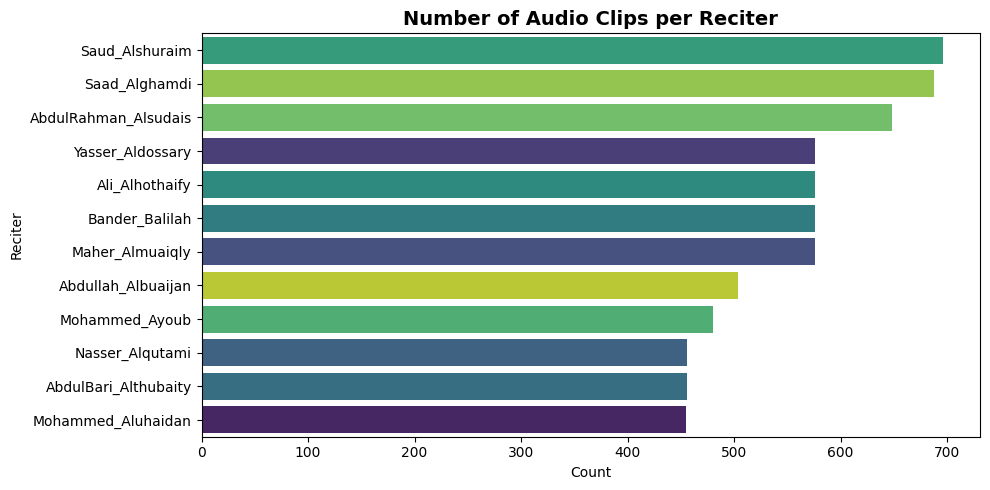

⏱️ Analyzing audio durations (sampling 200 files)...
   Found 200/200 valid files.
   Min duration: 2.50s | Max duration: 5.00s | Mean: 2.99s


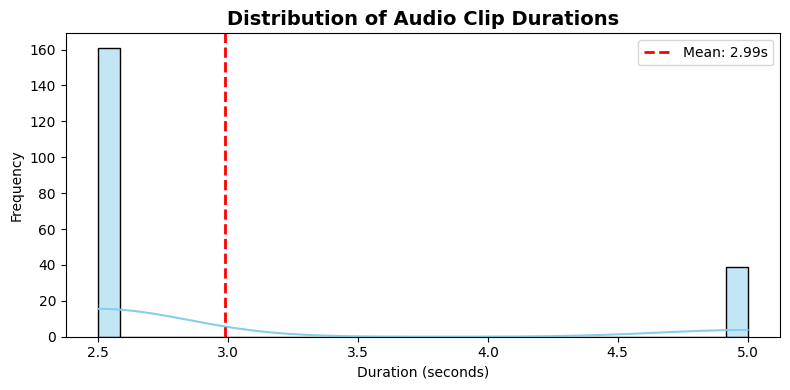

🎵 Visualizing Raw Waveform vs. Mel Spectrogram...
   ✅ Found valid file: lohaidan_171.wav


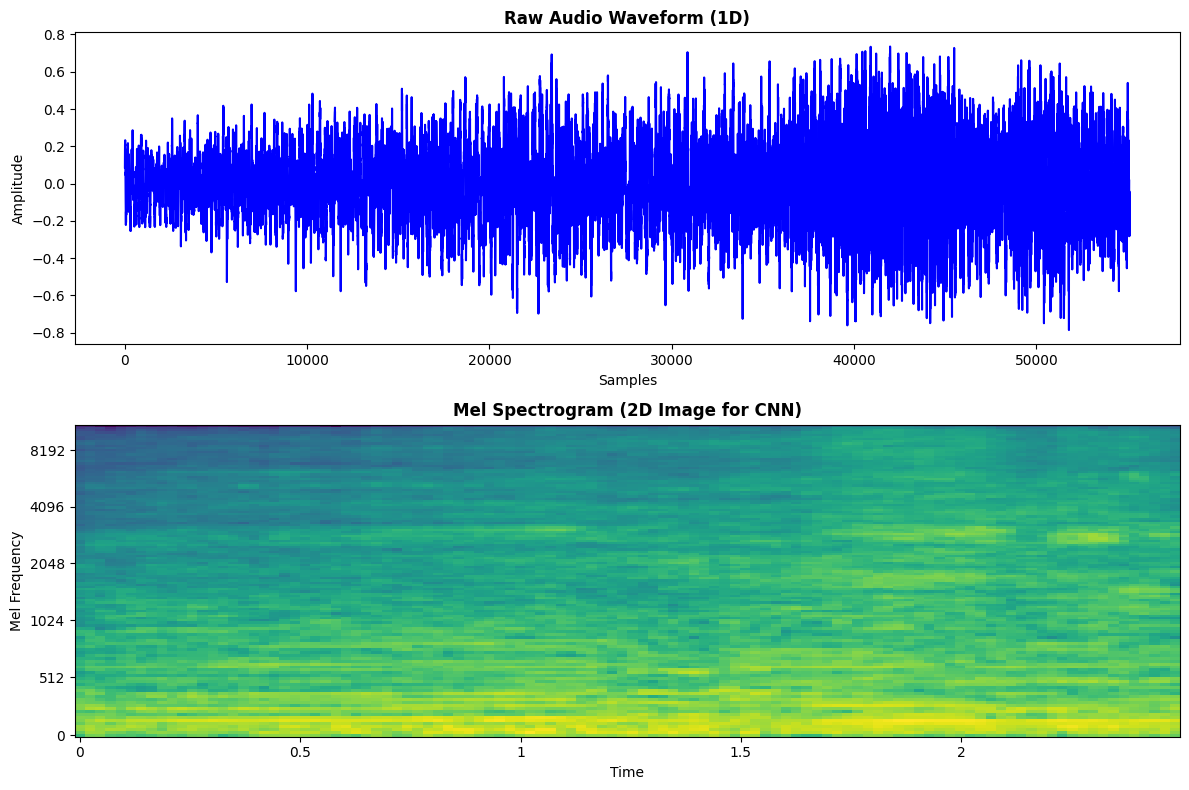

In [17]:
# 1. Class Distribution
plot_class_distribution(df_inspect, LABEL_COL)

# 2. Audio Durations
analyze_audio_durations(df_inspect, DATASET_ROOT, PATH_COL, sample_size=200)

# 3. Waveform vs Spectrogram Visualization
visualize_waveform_and_spectrogram(df_inspect, DATASET_ROOT, PATH_COL, CONFIG['sample_rate'])

#  Audio Dataset & DataLoader

In [21]:


# --- Label Encoding ---
# Neural networks need integer labels (0, 1, 2...), not strings ('Ali', 'Saad'...)
le = LabelEncoder()
df_inspect['label_idx'] = le.fit_transform(df_inspect[LABEL_COL])

# Save classes to CONFIG for the inference demo later
CONFIG['num_classes'] = len(le.classes_)
CONFIG['classes'] = le.classes_.tolist()

print(f"✅ Encoded {CONFIG['num_classes']} reciters.")
print(f"   Classes: {CONFIG['classes']}")

# --- Robust Path Fixing (Applying our EDA fix to the whole DataFrame) ---
def fix_all_paths(df: pd.DataFrame, base_dir: Path, path_col: str) -> pd.DataFrame:
    """Applies the robust path finding to the entire DataFrame to ensure DataLoader doesn't crash."""
    print("️ Fixing and verifying all audio paths in the DataFrame...")
    valid_paths = []
    valid_labels = []
    valid_indices = []
    
    # We use a subset of the logic to find valid files quickly
    for idx, row in df.iterrows():
        clean_path = row[path_col].replace('./', '').replace('\\', '/')
        p1 = base_dir / clean_path
        p2 = base_dir / "Dataset" / clean_path.replace('Dataset/', '')
        
        actual_path = None
        if p1.exists(): actual_path = p1
        elif p2.exists(): actual_path = p2
        else:
            # Fallback search
            filename = Path(clean_path).name
            matches = list(base_dir.rglob(filename))
            if matches: actual_path = matches[0]
            
        if actual_path:
            valid_paths.append(str(actual_path))
            valid_labels.append(row['label_idx'])
            valid_indices.append(idx)
            
    new_df = pd.DataFrame({'audio_path': valid_paths, 'label_idx': valid_labels})
    print(f"   Found {len(new_df)} valid audio files out of {len(df)}.")
    return new_df

# Create a clean DataFrame with absolute, valid paths
df_clean = fix_all_paths(df_inspect, DATASET_ROOT, PATH_COL)

# --- Train / Val / Test Split (Stratified) ---
# 80% Train, 10% Val, 10% Test
df_train, df_temp = train_test_split(df_clean, test_size=0.2, random_state=CONFIG['seed'], stratify=df_clean['label_idx'])
df_val, df_test = train_test_split(df_temp, test_size=0.5, random_state=CONFIG['seed'], stratify=df_temp['label_idx'])

print(f"\n📊 Final Split Sizes:")
print(f"   Train: {len(df_train)}")
print(f"   Val:   {len(df_val)}")
print(f"   Test:  {len(df_test)}")

✅ Encoded 12 reciters.
   Classes: ['AbdulBari_Althubaity', 'AbdulRahman_Alsudais', 'Abdullah_Albuaijan', 'Ali_Alhothaify', 'Bander_Balilah', 'Maher_Almuaiqly', 'Mohammed_Aluhaidan', 'Mohammed_Ayoub', 'Nasser_Alqutami', 'Saad_Alghamdi', 'Saud_Alshuraim', 'Yasser_Aldossary']
️ Fixing and verifying all audio paths in the DataFrame...
   Found 6687 valid audio files out of 6687.

📊 Final Split Sizes:
   Train: 5349
   Val:   669
   Test:  669


In [29]:


class QuranAudioDataset(Dataset):
    """
    Custom Dataset that loads .wav files and converts them to Mel Spectrograms on the fly.
    """
    def __init__(
        self, 
        df: pd.DataFrame, 
        sample_rate: int, 
        n_mels: int
    ) -> None:
        self.df = df.reset_index(drop=True)
        self.sample_rate = sample_rate
        self.n_mels = n_mels
        
    def __len__(self) -> int:
        return len(self.df)
        
    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        # Get absolute path and label
        audio_path = self.df.iloc[idx]['audio_path']
        label = self.df.iloc[idx]['label_idx']
        
        # 1. Load Audio
        y, _ = librosa.load(audio_path, sr=self.sample_rate)
        
        # 2. Convert to Mel Spectrogram
        mel_spec = librosa.feature.melspectrogram(y=y, sr=self.sample_rate, n_mels=self.n_mels)
        
        # 3. Convert to Decibels (Log scale)
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
        
        # 4. Convert to Tensor and add Channel Dimension [1, n_mels, time]
        mel_tensor = torch.FloatTensor(mel_spec_db).unsqueeze(0)
        
        # 5. Return tensor and integer label
        return mel_tensor, torch.tensor(label, dtype=torch.long)

def pad_collate(batch: List[Tuple[torch.Tensor, torch.Tensor]]) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Custom collate function to handle variable-length spectrograms in a batch.
    Pads all tensors in the batch to the length of the longest tensor in that specific batch.
    """
    # Separate tensors and labels
    tensors, labels = zip(*batch)
    
    # Find the maximum time dimension (width) in this specific batch
    max_len = max(t.size(2) for t in tensors)
    
    # Pad tensors to match the max_len
    padded_tensors = []
    for t in tensors:
        pad_size = max_len - t.size(2)
        if pad_size > 0:
            # Pad the last dimension (time) with zeros: (left, right, top, bottom) -> (0, pad_size, 0, 0)
            t = torch.nn.functional.pad(t, (0, pad_size)) 
        padded_tensors.append(t)
        
    # CRITICAL: You must return the stacked tensors and labels!
    return torch.stack(padded_tensors), torch.stack(labels)

In [ ]:
# 1. Create Datasets
train_dataset = QuranAudioDataset(df_train, CONFIG['sample_rate'], CONFIG['img_size'][0])
val_dataset = QuranAudioDataset(df_val, CONFIG['sample_rate'], CONFIG['img_size'][0])
test_dataset = QuranAudioDataset(df_test, CONFIG['sample_rate'], CONFIG['img_size'][0])

# 2. Create DataLoaders
train_loader = DataLoader(
    train_dataset, 
    batch_size=CONFIG['batch_size'], 
    shuffle=True, 
    num_workers=CONFIG['num_workers'],
    collate_fn=pad_collate,  # Uses our custom padding function
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=CONFIG['batch_size'], 
    shuffle=False, 
    num_workers=CONFIG['num_workers'],
    collate_fn=pad_collate,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=CONFIG['batch_size'], 
    shuffle=False, 
    num_workers=CONFIG['num_workers'],
    collate_fn=pad_collate,
    pin_memory=True
)

# 3. Verify a Batch
print("\n🔍 Verifying DataLoader output...")
images, labels = next(iter(train_loader))
print(f"   Batch Input Shape: {images.shape}  <-- [Batch, Channels(1), Mel Bands(128), Variable Time]")
print(f"   Batch Labels Shape: {labels.shape}")
print(f"   Sample Label Indices: {labels[:5].numpy()}")
print(f"   Sample Reciter Names: {[CONFIG['classes'][i] for i in labels[:5].numpy()]}")


🔍 Verifying DataLoader output...
   Batch Input Shape: torch.Size([32, 1, 128, 216])  <-- [Batch, Channels(1), Mel Bands(128), Variable Time]
   Batch Labels Shape: torch.Size([32])
   Sample Label Indices: [1 4 1 9 4]
   Sample Reciter Names: ['AbdulRahman_Alsudais', 'Bander_Balilah', 'AbdulRahman_Alsudais', 'Saad_Alghamdi', 'Bander_Balilah']


# VGG architecture blocks

In [33]:


class VGGAudioCNN(nn.Module):

    def __init__(self, num_classes: int, dropout_rate: float = 0.3) -> None:
        super(VGGAudioCNN, self).__init__()
        
        # --- Feature Extractor (VGG-style blocks) ---
        # Block 1: Extracts basic frequency edges and breath patterns
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        # Block 2: Extracts harmonic structures and vowel/consonant boundaries
        self.block2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        # Block 3: Extracts reciter-specific timbre and vocal tract resonance
        self.block3 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        # --- The "Magic" Layer: Global Average Pooling ---
        # Collapses the variable time dimension and frequency dimension into a 1x1 grid
        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        # --- Classifier Head ---
        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout_rate),
            nn.Linear(in_features=128, out_features=num_classes)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x shape: [Batch, 1, 128, Variable_Time]
        
        # Pass through convolutional blocks
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        
        # Apply Global Average Pooling
        # x shape becomes: [Batch, 128, 1, 1]
        x = self.global_avg_pool(x)
        
        # Flatten to [Batch, 128]
        x = x.view(x.size(0), -1)
        
        # Pass through classifier head
        x = self.classifier(x)
        
        return x

def count_parameters(model: nn.Module) -> Tuple[int, int]:
    """Counts trainable and total parameters."""
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return trainable, total

In [34]:
# 1. Instantiate the model
model = VGGAudioCNN(
    num_classes=CONFIG['num_classes'], 
    dropout_rate=CONFIG['dropout_rate']
).to(DEVICE)

# 2. Print Model Summary
trainable_params, total_params = count_parameters(model)
print("="*50)
print("MODEL ARCHITECTURE SUMMARY")
print("="*50)
print(f"Target Classes: {CONFIG['num_classes']} Reciters")
print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")
print("="*50)

# 3. Verify with a Dummy Batch (Proves variable-length handling works!)
print("\n🔍 Verifying forward pass with variable lengths...")
model.eval()

# Simulate a batch of 4 clips with DIFFERENT time lengths (widths)
dummy_batch = torch.randn(4, 1, 128, 150).to(DEVICE)  # 150 time steps
dummy_batch_2 = torch.randn(4, 1, 128, 250).to(DEVICE) # 250 time steps

with torch.no_grad():
    out1 = model(dummy_batch)
    out2 = model(dummy_batch_2)

print(f"   Input 1 Shape: {dummy_batch.shape} -> Output Shape: {out1.shape}")
print(f"   Input 2 Shape: {dummy_batch_2.shape} -> Output Shape: {out2.shape}")
print("\n✅ Model successfully handles variable-length audio without padding!")

MODEL ARCHITECTURE SUMMARY
Target Classes: 12 Reciters
Total Parameters: 288,876
Trainable Parameters: 288,876

🔍 Verifying forward pass with variable lengths...
   Input 1 Shape: torch.Size([4, 1, 128, 150]) -> Output Shape: torch.Size([4, 12])
   Input 2 Shape: torch.Size([4, 1, 128, 250]) -> Output Shape: torch.Size([4, 12])

✅ Model successfully handles variable-length audio without padding!


# Training Loop

In [36]:


def setup_training_components(model: nn.Module, config: dict) -> Tuple[nn.Module, optim.Optimizer, lr_scheduler.ReduceLROnPlateau]:

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=config['learning_rate'])

    scheduler = lr_scheduler.ReduceLROnPlateau(
        optimizer, 
        mode='min',       # We want to minimize the validation loss
        factor=0.5,       # Multiply LR by 0.5 when triggered
        patience=5        # Wait 5 epochs of no improvement before dropping
    )
    
    print("✅ Training components initialized!")
    return criterion, optimizer, scheduler

In [38]:

def train_model(
    model: nn.Module,
    train_loader: torch.utils.data.DataLoader,
    val_loader: torch.utils.data.DataLoader,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    scheduler: lr_scheduler.ReduceLROnPlateau,
    num_epochs: int,
    device: torch.device,
    early_stopping_patience: int = 7
) -> dict:
    """
    Trains the model, applies LR scheduling, and uses early stopping.
    """
    print(f"\n🚀 Starting training for up to {num_epochs} epochs on {device}...")
    print(f"⏳ Early stopping patience set to {early_stopping_patience} epochs.\n")
    
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    # Early stopping variables
    best_val_loss = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0
    
    for epoch in range(num_epochs):
        # --- TRAINING PHASE ---
        model.train()
        running_train_loss = 0.0
        running_train_corrects = 0
        train_total = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_train_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            running_train_corrects += torch.sum(preds == labels.data)
            train_total += images.size(0)
            
        epoch_train_loss = running_train_loss / train_total
        epoch_train_acc = running_train_corrects.double() / train_total
        
        # --- VALIDATION PHASE ---
        model.eval()
        running_val_loss = 0.0
        running_val_corrects = 0
        val_total = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                running_val_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                running_val_corrects += torch.sum(preds == labels.data)
                val_total += images.size(0)
                
        epoch_val_loss = running_val_loss / val_total
        epoch_val_acc = running_val_corrects.double() / val_total
        
        # --- SCHEDULER STEP ---
        scheduler.step(epoch_val_loss)
        
        # --- EARLY STOPPING LOGIC ---
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            
        # Save to history
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc.item())
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc.item())
        
        # Print progress every 5 epochs to keep the console clean
        current_lr = optimizer.param_groups[0]['lr']
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] | LR: {current_lr:.6f} | "
                  f"Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f} | "
                  f"Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}")
                  
        # Check if we should stop early
        if epochs_no_improve >= early_stopping_patience:
            print(f"\n🛑 Early stopping triggered at epoch {epoch + 1}. No improvement for {early_stopping_patience} epochs.")
            break
            
    # Restore the best model weights before finishing
    model.load_state_dict(best_model_wts)
    print(f"\n✅ Training completed! Restored best model weights (Val Loss: {best_val_loss:.4f}).")
    return history

In [39]:
criterion, optimizer, scheduler = setup_training_components(model, CONFIG)

# 2. Run the training loop
training_history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=CONFIG['num_epochs'],
    device=DEVICE,
    early_stopping_patience=7
)

✅ Training components initialized!

🚀 Starting training for up to 30 epochs on cuda...
⏳ Early stopping patience set to 7 epochs.

Epoch [1/30] | LR: 0.001000 | Train Loss: 2.1581 Acc: 0.2629 | Val Loss: 4.3557 Acc: 0.0972
Epoch [5/30] | LR: 0.001000 | Train Loss: 0.5178 Acc: 0.8847 | Val Loss: 0.5294 Acc: 0.8311
Epoch [10/30] | LR: 0.001000 | Train Loss: 0.1722 Acc: 0.9613 | Val Loss: 0.1855 Acc: 0.9552
Epoch [15/30] | LR: 0.001000 | Train Loss: 0.0794 Acc: 0.9841 | Val Loss: 0.0868 Acc: 0.9791
Epoch [20/30] | LR: 0.001000 | Train Loss: 0.0843 Acc: 0.9796 | Val Loss: 0.0708 Acc: 0.9836
Epoch [25/30] | LR: 0.001000 | Train Loss: 0.0399 Acc: 0.9907 | Val Loss: 0.0296 Acc: 0.9925
Epoch [30/30] | LR: 0.001000 | Train Loss: 0.0413 Acc: 0.9910 | Val Loss: 0.0894 Acc: 0.9731

✅ Training completed! Restored best model weights (Val Loss: 0.0212).


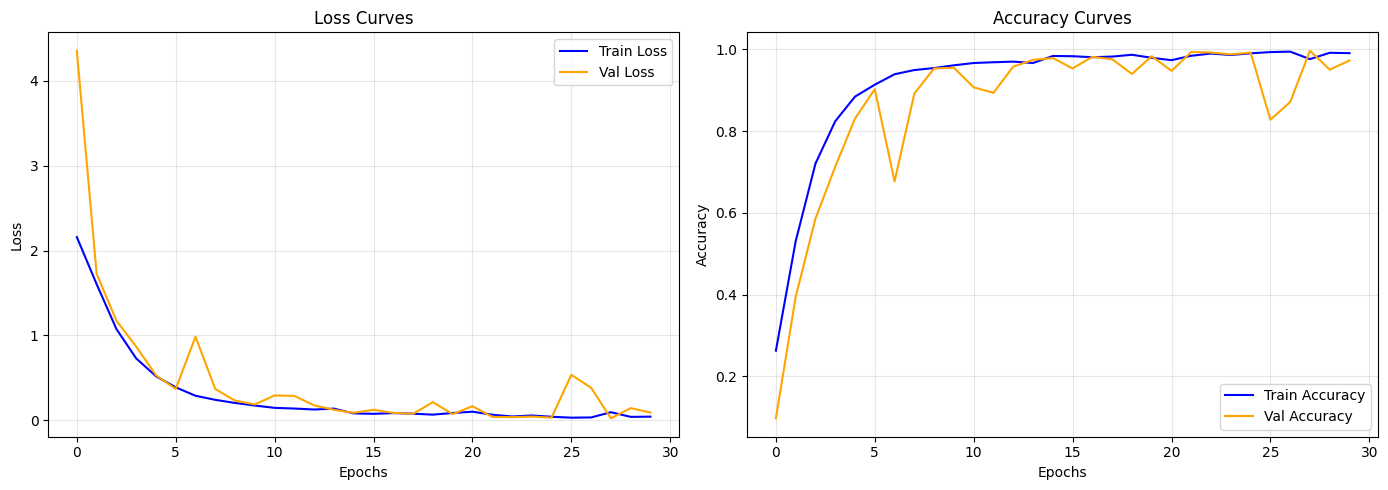

In [40]:
import matplotlib.pyplot as plt
from typing import Dict, List

def plot_training_curves(history: Dict[str, List[float]]) -> None:
    """
    Plots the training and validation loss and accuracy curves over epochs.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot Loss
    ax1.plot(history['train_loss'], label='Train Loss', color='blue')
    ax1.plot(history['val_loss'], label='Val Loss', color='orange')
    ax1.set_title('Loss Curves')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot Accuracy
    ax2.plot(history['train_acc'], label='Train Accuracy', color='blue')
    ax2.plot(history['val_acc'], label='Val Accuracy', color='orange')
    ax2.set_title('Accuracy Curves')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Execute the plot
plot_training_curves(training_history)

In [41]:
import torch.nn as nn
import torch

def evaluate_test_set(
    model: nn.Module, 
    test_loader: torch.utils.data.DataLoader, 
    criterion: nn.Module, 
    device: torch.device,
    target_accuracy: float = 0.70
) -> None:
    """
    Evaluates the model on the completely unseen test set.
    """
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    total_samples = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels.data)
            total_samples += images.size(0)
            
    final_loss = running_loss / total_samples
    final_accuracy = running_corrects.double() / total_samples
    
    print("="*50)
    print("FINAL TEST SET RESULTS (Unseen Audio)")
    print("="*50)
    print(f"Test Loss:     {final_loss:.4f}")
    print(f"Test Accuracy: {final_accuracy * 100:.2f}%")
    print("="*50)
    
    if final_accuracy >= target_accuracy:
        print(f"🎉 SUCCESS! You have met or exceeded the {target_accuracy*100:.0f}% target accuracy!")
    else:
        print(f"⚠️ Target not met. Consider adjusting hyperparameters.")

# Run the evaluation
evaluate_test_set(model, test_loader, criterion, DEVICE, target_accuracy=0.70)

FINAL TEST SET RESULTS (Unseen Audio)
Test Loss:     0.0201
Test Accuracy: 99.55%
🎉 SUCCESS! You have met or exceeded the 70% target accuracy!


In [43]:
import os
from google.colab import files

WEIGHTS_PATH = "quran_reciter_vgg.pth"

# 1. Check if the file exists
if os.path.exists(WEIGHTS_PATH):
    file_size = os.path.getsize(WEIGHTS_PATH)
    print(f"✅ File found! Size: {file_size / 1024:.2f} KB")
    
    # 2. Force download
    print("📥 Triggering download... (Check your browser's download bar)")
    files.download(WEIGHTS_PATH)
else:
    print(f"❌ File not found! Let's save it again.")
    torch.save(model.state_dict(), WEIGHTS_PATH)
    files.download(WEIGHTS_PATH)

✅ File found! Size: 1146.89 KB
📥 Triggering download... (Check your browser's download bar)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [46]:
!ls -lh quran_reciter_vgg.pth

-rw-r--r-- 1 root root 1.2M Jun 17 03:20 quran_reciter_vgg.pth


In [47]:
import base64
from IPython.display import HTML, display

# 1. Read the file and encode it into base64
with open("quran_reciter_vgg.pth", "rb") as f:
    b64_data = base64.b64encode(f.read()).decode('utf-8')

# 2. Create an HTML anchor tag with the data stream
download_link = f'''
<a href="data:application/octet-stream;base64,{b64_data}" 
   download="quran_reciter_vgg.pth" 
   style="padding: 10px 20px; background-color: #007acc; color: white; text-decoration: none; border-radius: 5px; font-weight: bold;">
   ⬇️ Click here to download model weights
</a>
'''

# 3. Display the clickable button in the notebook output
display(HTML(download_link))

# inference demo

In [48]:
import gradio as gr
import librosa
import numpy as np
import torch
from typing import Tuple

def predict_reciter(audio_file_path: str) -> str:
    """
    Takes a raw audio file path, converts it to a Mel Spectrogram, 
    and returns the predicted Quran reciter with confidence.
    """
    # 1. Load Audio (Must match training sample rate)
    y, sr = librosa.load(audio_file_path, sr=CONFIG['sample_rate'])
    
    # 2. Convert to Mel Spectrogram (Must match training n_mels)
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=CONFIG['img_size'][0])
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    
    # 3. Convert to PyTorch Tensor [Batch, Channels, Height, Width]
    # We add two dimensions: one for the batch, one for the single grayscale channel
    input_tensor = torch.FloatTensor(mel_spec_db).unsqueeze(0).unsqueeze(0).to(DEVICE)
    
    # 4. Run Inference
    model.eval()
    with torch.no_grad():
        outputs = model(input_tensor)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        confidence, predicted_idx = torch.max(probabilities, 1)
        
    # 5. Format Output
    predicted_reciter = CONFIG['classes'][predicted_idx.item()]
    confidence_score = confidence.item() * 100
    
    return f"🎙️ Predicted Reciter: {predicted_reciter}\n📊 Confidence: {confidence_score:.2f}%"

# --- Create and Launch Gradio Demo ---
def launch_demo() -> None:
    """Creates and launches the Gradio interface for the Quran Reciter Identifier."""
    print("🚀 Launching Gradio Demo...")
    
    demo = gr.Interface(
        fn=predict_reciter,
        inputs=gr.Audio(type="filepath", label="Upload Quran Recitation (.wav/.mp3)"),
        outputs=gr.Textbox(label="Model Prediction"),
        title="🕌 Quran Reciter Identifier",
        description="""
        Upload an audio clip of a Quran recitation. 
        The model will analyze the vocal timbre and pitch using a Mel Spectrogram 
        and identify the reciter from 12 different classes.
        """,
        allow_flagging="never"
    )
    
    # share=True generates a public URL, which is highly recommended 
    # when running inside VS Code Colab extension or restricted networks.
    demo.launch(share=True)

# Execute the demo
launch_demo()

🚀 Launching Gradio Demo...


/usr/local/lib/python3.12/dist-packages/gradio/interface.py:415: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated. Use `flagging_mode` instead.
  warnings.warn(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://56f440141cd4bcc35e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
